<a href="https://colab.research.google.com/github/nguoitinhmuadong-1/palmistry_app/blob/main/CNNpalmistry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install ultralytics roboflow


In [ ]:
!cp "/content/palmistry_yolo_best.pt" "/content/drive/MyDrive/palmistry_yolo_best.pt"

In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/palmistry_yolo_best.pt"))

True


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/palmistry_yolo_best.pt")

print("Load model thành công")

Load model thành công


In [ ]:
!pip install roboflow

from roboflow import Roboflow

rf = Roboflow(api_key="eLsE9SXFEiri8wKCzHSs")
project = rf.workspace("palmistry-2klz8").project("palmistry-g45zz")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
import os
print(os.listdir("/content"))

['.config', 'drive', 'Palmistry-1', 'palmistry_yolo_best.pt', 'sample_data']


In [ ]:
import os
import cv2
import shutil
import numpy as np
from pathlib import Path

yolo_dataset_dir = "/content/Palmistry-1"
cnn_output_dir = "/content/drive/MyDrive/palmistry_cnn_quality_dataset"

if os.path.exists(cnn_output_dir):
    shutil.rmtree(cnn_output_dir)

os.makedirs(os.path.join(cnn_output_dir, "clear_line"), exist_ok=True)
os.makedirs(os.path.join(cnn_output_dir, "blur_line"), exist_ok=True)

def sharpness_score(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

all_crops = []

def collect_crops(split_name):
    images_dir = os.path.join(yolo_dataset_dir, split_name, "images")
    labels_dir = os.path.join(yolo_dataset_dir, split_name, "labels")

    if not os.path.exists(images_dir):
        print("Không thấy thư mục:", images_dir)
        return

    for img_name in os.listdir(images_dir):
        if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path = os.path.join(images_dir, img_name)
        label_path = os.path.join(labels_dir, Path(img_name).stem + ".txt")

        if not os.path.exists(label_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w, _ = img.shape

        with open(label_path, "r") as f:
            lines = f.readlines()

        for i, line in enumerate(lines):
            parts = line.strip().split()

            if len(parts) < 5:
                continue

            x_center = float(parts[1]) * w
            y_center = float(parts[2]) * h
            box_width = float(parts[3]) * w
            box_height = float(parts[4]) * h

            x1 = int(x_center - box_width / 2)
            y1 = int(y_center - box_height / 2)
            x2 = int(x_center + box_width / 2)
            y2 = int(y_center + box_height / 2)

            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(w, x2)
            y2 = min(h, y2)

            crop = img[y1:y2, x1:x2]

            if crop.size == 0:
                continue

            if crop.shape[0] < 20 or crop.shape[1] < 20:
                continue

            score = sharpness_score(crop)

            all_crops.append({
                "image": crop,
                "score": score,
                "name": f"{split_name}_{Path(img_name).stem}_{i}.jpg"
            })

collect_crops("train")
collect_crops("valid")
collect_crops("test")

print("Tổng ảnh crop:", len(all_crops))

scores = [item["score"] for item in all_crops]
threshold = np.median(scores)

print("Ngưỡng rõ/mờ:", threshold)

clear_count = 0
blur_count = 0

for item in all_crops:
    if item["score"] >= threshold:
        save_dir = os.path.join(cnn_output_dir, "clear_line")
        clear_count += 1
    else:
        save_dir = os.path.join(cnn_output_dir, "blur_line")
        blur_count += 1

    save_path = os.path.join(save_dir, item["name"])
    cv2.imwrite(save_path, item["image"])

print("clear_line:", clear_count)
print("blur_line:", blur_count)
print("Dataset CNN nằm ở:", cnn_output_dir)

Tổng ảnh crop: 10024
Ngưỡng rõ/mờ: 386.9190693077542
clear_line: 5012
blur_line: 5012
Dataset CNN nằm ở: /content/drive/MyDrive/palmistry_cnn_quality_dataset


In [ ]:
import os

cnn_dir = "/content/drive/MyDrive/palmistry_cnn_quality_dataset"

for folder in os.listdir(cnn_dir):
    folder_path = os.path.join(cnn_dir, folder)
    if os.path.isdir(folder_path):
        print(folder, ":", len(os.listdir(folder_path)), "ảnh")

clear_line : 5012 ảnh
blur_line : 5012 ảnh


Found 8020 images belonging to 2 classes.
Found 2004 images belonging to 2 classes.
Tên class: {'blur_line': 0, 'clear_line': 1}


Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
502/502 ━━━━━━━━━━━━━━━━━━━━ 1275s 3s/step - accuracy: 0.8296 - loss: 0.4057 - val_accuracy: 0.9027 - val_loss: 0.2326
Epoch 2/10
502/502 ━━━━━━━━━━━━━━━━━━━━ 1155s 2s/step - accuracy: 0.9190 - loss: 0.1983 - val_accuracy: 0.9057 - val_loss: 0.2100
Epoch 3/10
502/502 ━━━━━━━━━━━━━━━━━━━━ 1150s 2s/step - accuracy: 0.9226 - loss: 0.1818 - val_accuracy: 0.9222 - val_loss: 0.1800
Epoch 4/10
502/502 ━━━━━━━━━━━━━━━━━━━━ 1141s 2s/step - accuracy: 0.9296 - loss: 0.1687 - val_accuracy: 0.9207 - val_loss: 0.1750
Epoch 5/10
502/502 ━━━━━━━━━━━━━━━━━━━━ 1153s 2s/step - accuracy: 0.9348 - loss: 0.1604 - val_accuracy: 0.9162 - val_loss: 0.1865
Epoch 6/10
502/502 ━━━━━━━━━━━━━━━━━━━━ 1165s 2s/step - accuracy: 0.9335 - loss: 0.1582 - val_accuracy: 0.9192 - val_loss: 0.1742
Epoch 7/10
502/502 ━━━━━━━━━━━━━━━━━━━━ 1156s 2s/step - accuracy: 0.9367 - loss: 0.1515 - val_accuracy: 0.9406 - val_loss: 0.1565
Epoch 8/10
502/502 ━━━━━━━━━━━━━━━━━━━━ 1151s 2s/step - accuracy: 0.9453 - loss: 0.1385 - 

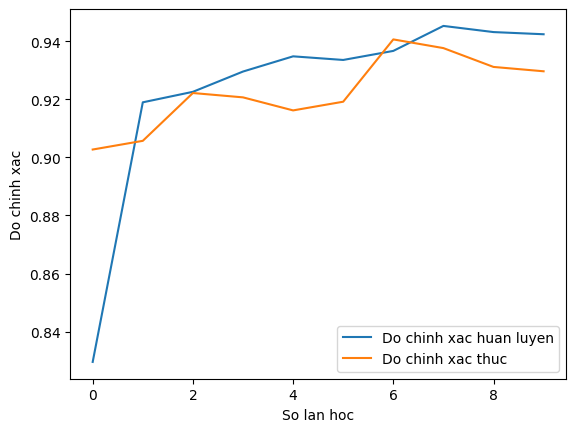

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

train_dir = "/content/drive/MyDrive/palmistry_cnn_quality_dataset"

img_width, img_height = 224, 224
batch_size = 16

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

num_classes = train_generator.num_classes

print("Tên class:", train_generator.class_indices)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

epochs = 10

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs
)

plt.plot(history.history['accuracy'], label='Do chinh xac huan luyen')
plt.plot(history.history['val_accuracy'], label='Do chinh xac thuc')
plt.xlabel('So lan hoc')
plt.ylabel('Do chinh xac')
plt.legend()
plt.show()

model.save("palmistry_cnn_quality.h5")




image 1/1 /content/{389DF4AD-D18E-4DE9-A451-3AC3256E3191}.png: 320x416 1 head, 1 heart, 1 life, 287.9ms
Speed: 7.7ms preprocess, 287.9ms inference, 3.3ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/predict-2
Ảnh kết quả nằm ở: /content/runs/detect/predict-2


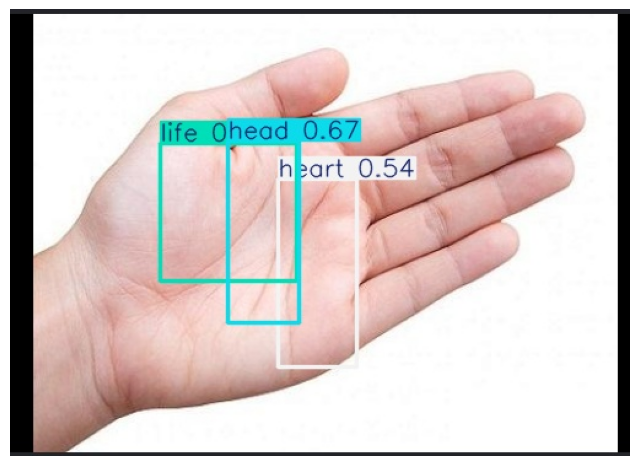

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import os

model = YOLO("/content/palmistry_yolo_best.pt")

image_path = "/content/{389DF4AD-D18E-4DE9-A451-3AC3256E3191}.png"

results = model.predict(
    source=image_path,
    conf=0.25,
    save=True
)

predict_dir = results[0].save_dir
print("Ảnh kết quả nằm ở:", predict_dir)

result_images = [f for f in os.listdir(predict_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
result_path = os.path.join(predict_dir, result_images[0])

img = Image.open(result_path)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()